# Anomaly Investigation: Amount Outliers by Category

Item 1 from the plan in `05_conclusions_next_steps.ipynb`: look for `amount` outliers that aren't already explained by the refund anomaly. New method for this dataset: **boxplots per category**, instead of the single-distribution histograms used in `01_eda.ipynb`.

Standalone notebook — reloads and prepares the data independently of `01_eda.ipynb`.

In [1]:
import pandas as pd

df = pd.read_csv('/home/veronika/Anomaly_Hunter_Solidgate/hackathon_int20h_dataset_test.csv')

In [2]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['processed_at'] = pd.to_datetime(df['processed_at'])

## Theory: reading a boxplot

A boxplot summarizes a distribution in five numbers: the box spans the 25th to 75th percentile (the IQR - the middle 50% of the data), the line inside is the median, and the whiskers extend to 1.5x the IQR beyond the box. Anything past the whiskers is drawn as an **individual point** - an explicit, visual list of outliers, rather than something you have to infer from a tail shape.

**Why a boxplot instead of the histograms already used in `01_eda.ipynb`:** a histogram shows the shape of one distribution well, but comparing many categories means many separate histograms, one per category, which doesn't scale. A boxplot per category can be placed side by side on one axis - `seaborn.boxplot(x='category', y='amount', data=df)` draws one box per category automatically. This is the same shift in tooling that section 9 already made for latency and fail rate (`pivot_table` + heatmap to scan every category at once instead of filtering one at a time) - here the equivalent move is one boxplot per category instead of one histogram at a time.

**Distant example, unrelated domain:** comparing standardized test scores across school classes. A boxplot per class instantly shows which specific student scored far outside their *own* class's usual range - even if that score would look unremarkable next to a much harder class's typical range. The comparison that matters is always relative to the right reference group, not to the whole school at once.

## Critical trap - re-read before writing any code

`amount` is stored in each transaction's **local currency**, and this dataset has 7 currencies (USD, CAD, EUR, UAH, GBP, PLN, MXN) with very different numeric scales. None of `payment_method`, `psp_id`, or `bin_country` maps cleanly to a single currency - so a boxplot of raw `amount` grouped by any of them would silently mix currencies inside the same box. This is the **exact same trap** as the currency-mixing bug in section 10 of `01_eda.ipynb` (summing `refund_gap` across currencies gave a misleading signal) - just applied to comparing distributions instead of summing them.

Two valid ways to handle it - pick one before building any boxplot below:
1. **Facet by currency** - build the category boxplot separately for each currency (e.g. `seaborn.catplot(..., col='currency')`), so every box only ever contains one currency's numbers.
2. **Standardize within currency first** - compute a z-score of `amount` *within each currency group* (subtract that currency's mean, divide by that currency's std) before combining across categories. This turns every currency's numbers into comparable units ("how many standard deviations from typical, for this currency") so a single combined boxplot becomes valid.

Check first whether currency mix is even roughly balanced across your grouping column (the same check already done for `psp_beta` in section 10) - if one category is dominated by a single currency, that's useful context either way.

## C1. Currency mix per category

Before comparing `amount` across `payment_method` / `psp_id` / `bin_country`, check how currency is distributed within each - reuse the same `groupby` + normalized counts approach from section 10's currency-mix check.

In [3]:
pd.crosstab(df['psp_id'], df['currency'], normalize='index')


currency,CAD,EUR,GBP,MXN,PLN,UAH,USD
psp_id,,,,,,,
psp_alpha,0.150605,0.119358,0.060632,0.050232,0.059435,0.059803,0.499936
psp_beta,0.149649,0.119864,0.060506,0.049519,0.059241,0.060440,0.500782
psp_gamma,0.149841,0.119756,0.059337,0.049679,0.060232,0.060458,0.500697


In [4]:
pd.crosstab(df['bin_country'], df['currency'], normalize='index')

currency,CAD,EUR,GBP,MXN,PLN,UAH,USD
bin_country,,,,,,,
CAN,0.879060,0.016821,0.008506,0.007350,0.008540,0.008315,0.071409
DEU,0.044008,0.743031,0.018628,0.013790,0.017493,0.016953,0.146098
FRA,0.042295,0.742888,0.018252,0.014514,0.017770,0.017600,0.146680
GBR,0.043552,0.035698,0.725452,0.013364,0.017785,0.017941,0.146209
MEX,0.051167,0.038648,0.019364,0.686459,0.020746,0.019557,0.164058
POL,0.045070,0.035576,0.017966,0.014361,0.723335,0.017653,0.146038
UKR,0.042659,0.033967,0.017343,0.014722,0.017188,0.727758,0.146363
USA,0.006879,0.005731,0.002870,0.002325,0.002642,0.002720,0.976833


In [5]:
pd.crosstab(df['payment_method'], df['currency'], normalize='index')

currency,CAD,EUR,GBP,MXN,PLN,UAH,USD
payment_method,,,,,,,
applepay,0.148934,0.118707,0.060641,0.049462,0.059892,0.060186,0.502180
card,0.150174,0.119692,0.060101,0.049953,0.059719,0.060176,0.500186
googlepay,0.150464,0.120457,0.059948,0.049489,0.058994,0.060549,0.500100


In [6]:
df['amount_zscore'] = df.groupby('currency')['amount'].transform(lambda x: (x - x.mean()) / x.std())

## C2. Amount distribution by `payment_method`

Boxplot of `amount` (currency-corrected per the trap above) across `card` / `applepay` / `googlepay`. Look for individual outlier points far outside a method's own box, and for whether one method's box is shaped very differently from the others.

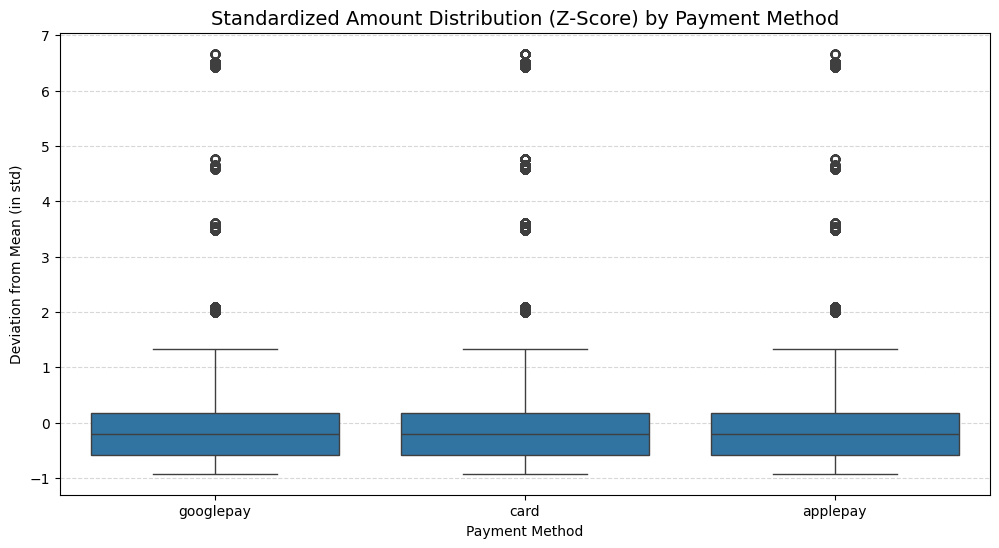

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(x='payment_method', y='amount_zscore', data=df)

plt.title('Standardized Amount Distribution (Z-Score) by Payment Method', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Deviation from Mean (in std)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

## C3. Amount distribution by `psp_id`

Same boxplot, grouped by `psp_id` instead.

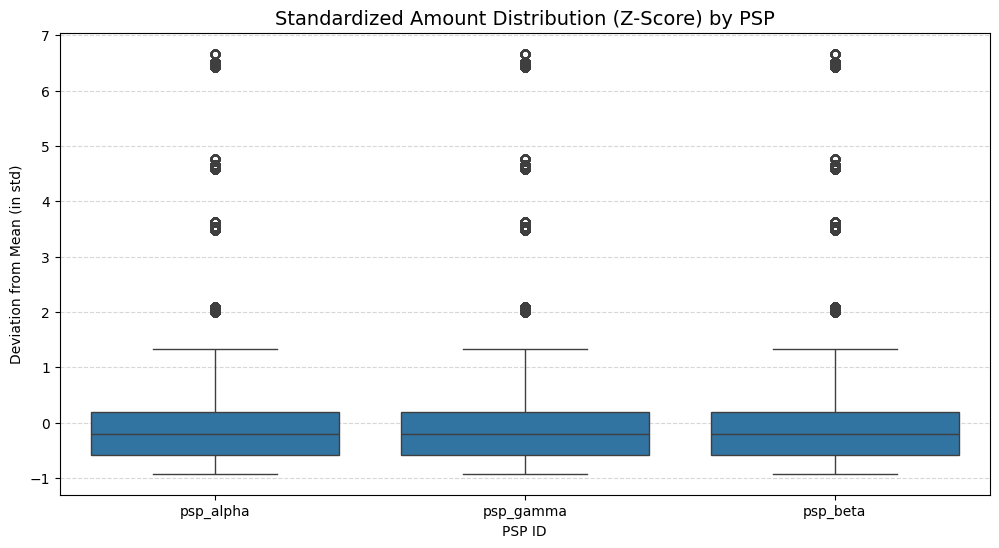

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='psp_id', y='amount_zscore', data=df)

plt.title('Standardized Amount Distribution (Z-Score) by PSP', fontsize=14)
plt.xlabel('PSP ID')
plt.ylabel('Deviation from Mean (in std)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

## C4. Amount distribution by `bin_country`

Same boxplot, grouped by `bin_country` instead. If any group produces outlier points, profile that subset with the escalation checklist below before deciding whether it's a real cluster.

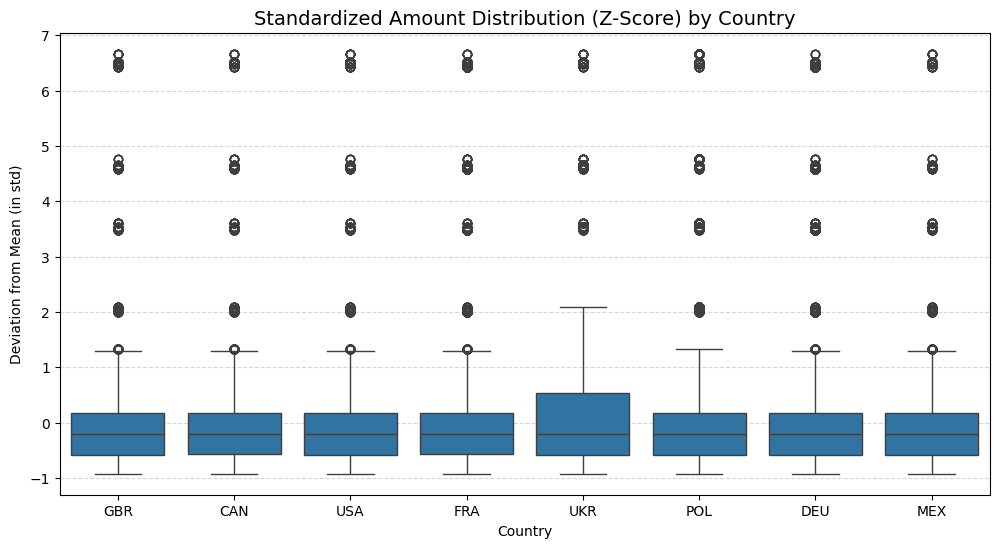

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='bin_country', y='amount_zscore', data=df)

plt.title('Standardized Amount Distribution (Z-Score) by Country', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Deviation from Mean (in std)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

In [10]:
for i in df['currency'].unique():
    currency_outliers = df[(df['currency'] == i) & (df['amount_zscore'].abs() > 3)]
    
    print(f"\nCurrency: {i} | Count of Outliers: {len(currency_outliers)}")
    
    print("Top Anomalous Amounts:")
    print(currency_outliers['amount'].value_counts())
    
    print("Distribution of Order Types among Outliers:")
    print(currency_outliers['order_type'].value_counts())


Currency: EUR | Count of Outliers: 2951
Top Anomalous Amounts:
amount
110.4    1466
184.0     779
138.0     706
Name: count, dtype: int64
Distribution of Order Types among Outliers:
order_type
recurring    2951
Name: count, dtype: int64

Currency: CAD | Count of Outliers: 3625
Top Anomalous Amounts:
amount
164.4    1820
274.0     909
205.5     896
Name: count, dtype: int64
Distribution of Order Types among Outliers:
order_type
recurring    3625
Name: count, dtype: int64

Currency: USD | Count of Outliers: 12031
Top Anomalous Amounts:
amount
120.0    6110
200.0    2990
150.0    2931
Name: count, dtype: int64
Distribution of Order Types among Outliers:
order_type
recurring    12031
Name: count, dtype: int64

Currency: UAH | Count of Outliers: 1425
Top Anomalous Amounts:
amount
4944.0    711
6180.0    362
8240.0    352
Name: count, dtype: int64
Distribution of Order Types among Outliers:
order_type
recurring    1425
Name: count, dtype: int64



Currency: PLN | Count of Outliers: 1312
Top Anomalous Amounts:
amount
482.4    652
804.0    334
603.0    326
Name: count, dtype: int64
Distribution of Order Types among Outliers:
order_type
recurring    1312
Name: count, dtype: int64

Currency: MXN | Count of Outliers: 1188
Top Anomalous Amounts:
amount
2220.0    555
2775.0    333
3700.0    300
Name: count, dtype: int64
Distribution of Order Types among Outliers:
order_type
recurring    1188
Name: count, dtype: int64

Currency: GBP | Count of Outliers: 1450
Top Anomalous Amounts:
amount
93.6     701
117.0    382
156.0    367
Name: count, dtype: int64
Distribution of Order Types among Outliers:
order_type
recurring    1450
Name: count, dtype: int64


In [11]:
recurring = df[df['order_type'] == 'recurring']
tiers = recurring.groupby('currency')['amount'].apply(
    lambda s: sorted(s.value_counts()[s.value_counts() > 1000].index)
)
print(tiers)

currency
CAD    [20.55, 27.4, 41.1, 54.8, 68.5, 82.2, 109.6, 1...
EUR    [13.8, 18.4, 27.6, 36.8, 46.0, 55.2, 73.6, 110.4]
GBP           [11.7, 15.6, 23.4, 31.2, 39.0, 46.8, 62.4]
MXN          [277.5, 370.0, 555.0, 740.0, 925.0, 1110.0]
PLN      [60.3, 80.4, 120.6, 160.8, 201.0, 241.2, 321.6]
UAH    [618.0, 824.0, 1236.0, 1648.0, 2060.0, 2472.0,...
USD    [15.0, 20.0, 30.0, 40.0, 50.0, 60.0, 80.0, 120...
Name: amount, dtype: object


**Finding:** every currency has its own fixed ladder of ~7-10 recurring-billing price points (e.g. USD: 15/20/30/40/50/60/80/120/150/200), converted proportionally in every other currency (UAH: 618/824/1236/1648/2060/2472/3296..., same ratios in the same order). The boxplot "outliers" in C2/C3 are simply the **top 2-3 tiers** of this ladder - the only ones far enough from the currency's mean to fall outside 1.5x IQR. 100% of these rows are `order_type == recurring`.

**Conclusion (C2/C3):** the repeated high-z-score points seen identically across `payment_method`, `psp_id`, and `bin_country` are a legitimate, fixed subscription pricing catalog, not an anomaly - they aren't tied to any of the three categories because the pricing catalog is global. No action needed for `is_anomaly`.

In [12]:
for order_type in ['first', 'recurring']:
    sub = df[df['order_type'] == order_type]
    q = sub.groupby('bin_country')['amount_zscore'].quantile([0.25, 0.75]).unstack()
    q.columns = ['q25', 'q75']
    q['iqr'] = q['q75'] - q['q25']
    print(order_type)
    print(q.sort_values('iqr', ascending=False))
    print()

first
                  q25       q75       iqr
bin_country                              
USA         -0.914757 -0.578808  0.335948
POL         -0.914757 -0.579079  0.335678
MEX         -0.913344 -0.578428  0.334915
CAN         -0.906557 -0.571646  0.334911
GBR         -0.908834 -0.575345  0.333488
DEU         -0.904930 -0.573751  0.331179
FRA         -0.904930 -0.573751  0.331179
UKR         -0.914757 -0.584678  0.330078



recurring
                  q25       q75       iqr
bin_country                              
UKR         -0.210556  0.909414  1.119971
USA         -0.205533  0.914294  1.119827
DEU         -0.204930  0.900334  1.105264
FRA         -0.204930  0.900334  1.105264
GBR         -0.203799  0.900334  1.104133
MEX         -0.205535  0.565148  0.770682
CAN         -0.198949  0.565148  0.764097
POL         -0.197670  0.565148  0.762818



**Finding:** for `first` (one-off purchases), IQR is nearly identical across all 8 countries (~0.33) - `bin_country` is not a factor here. For `recurring`, IQR is much wider everywhere (expected - this is where the pricing ladder from C2/C3 lives), but splits into two groups: `{UKR, USA, DEU, FRA, GBR}` (~1.10-1.12) vs `{MEX, CAN, POL}` (~0.76-0.77).

In [13]:
recurring = df[df['order_type'] == 'recurring']
print(recurring.groupby('bin_country')['amount_zscore'].mean().sort_values(ascending=False))

bin_country
GBR    0.445755
CAN    0.445321
FRA    0.444447
USA    0.444329
POL    0.443467
DEU    0.442743
UKR    0.442130
MEX    0.438808
Name: amount_zscore, dtype: float64


**Finding:** mean z-score for `recurring` is nearly flat across all 8 countries (0.439-0.446, a 0.007 range - noise). The typical tier chosen is the same everywhere; only the *spread* across tiers differs between the two groups above.

**Conclusion (C4):** no country-level anomaly. The IQR split is a 5-vs-3 country grouping, not a single outlier country, and it reflects variance in which pricing tiers get chosen, not a shift in the typical price - consistent with ordinary market-to-market variety in subscription tier popularity rather than an injected pattern. Closed, same treatment as `psp_alpha`.

**Follow-up - the time-profile step from the escalation checklist was skipped above, so it is added here.** Splitting the C4 IQR by week shows every country bouncing between the same two IQR regimes (~0.75 and ~1.10-1.11), with weak/inconsistent correlation between countries week to week - not a stable per-country trait. This is a symptom of a deeper issue: `amount` for `recurring` transactions only takes ~10 fixed values (the price ladder from C2/C3), so it is effectively categorical, not continuous - IQR computed on a small weekly sample of a near-discrete variable can jump between adjacent tiers from tiny proportion shifts, mimicking a "spread difference" that is not really there. IQR was the wrong tool for a variable this discrete.

In [14]:
rec = df[df['order_type'] == 'recurring'].copy()
rec['tier_rank'] = rec.groupby('currency')['amount'].rank(method='dense')

tier_mix = pd.crosstab(rec['bin_country'], rec['tier_rank'], normalize='index') * 100
print(tier_mix.round(2))

tier_rank     1.0    2.0    3.0    4.0    5.0   6.0   7.0   8.0   9.0   10.0
bin_country                                                                 
CAN          15.09  24.86  20.10  15.03   9.89  8.09  2.94  2.00  1.00  0.99
DEU          14.97  24.94  20.09  14.67  10.05  8.20  3.04  1.98  0.95  1.10
FRA          15.33  24.89  19.58  14.89   9.99  8.16  3.01  2.05  1.03  1.07
GBR          14.86  24.91  20.26  14.84   9.92  8.16  3.03  1.94  1.04  1.05
MEX          14.98  24.97  20.09  15.07  10.22  7.72  2.96  1.96  1.04  0.98
POL          14.96  24.94  20.00  15.30  10.21  8.07  2.84  1.89  0.90  0.89
UKR          14.84  25.23  19.59  15.02  10.13  8.13  3.08  1.99  1.00  0.98
USA          14.89  25.05  19.93  14.99  10.09  8.04  2.98  2.04  0.99  1.00


**Finding (corrected, decisive test):** ranking each currency's price tiers 1 (cheapest) to 10 (priciest) and comparing tier-choice proportions per country - the right tool for a categorical variable - shows all 8 countries within a few hundredths of a percentage point of each other on every single rank. `bin_country`, including `UKR`, has no effect on which tier gets chosen.

**Conclusion (C4, final):** the IQR-based grouping was a discreteness artifact, not a real signal. The categorical tier-mix check confirms no country-level pattern at all. Closed with high confidence.

## Escalation checklist

Same as `06_anomaly_invariant_checks.ipynb`: exact count and share, `nunique()`/`value_counts()` on the violating subset, constant vs variable magnitude, time profile (single day / bounded window / scattered), and whether the group explains 100% of a related metric for the year.

## Conclusions

| Check | Result | Verdict |
|---|---|---|
| C1: currency mix per category | `payment_method`/`psp_id` balanced across currencies; `bin_country` is a near-proxy for currency (70-98% one currency each) | Informs method (z-score within currency) for C2-C4 |
| C2/C3: amount by `payment_method` / `psp_id` | High-z-score points are a fixed, global recurring-billing price ladder (7-10 tiers per currency), 100% `order_type == recurring` | Legitimate pricing catalog, not a signal |
| C4: amount by `bin_country` | Initial IQR split (5 vs 3 countries) was a discreteness artifact - `amount` has only ~10 fixed values for `recurring`, so quantiles misbehave; categorical tier-mix check (crosstab, normalized) shows all 8 countries within hundredths of a percentage point on every tier | No country-level pattern, including `UKR` |

No new anomaly cluster found. Folded into `05_conclusions_next_steps.ipynb`.